https://medium.com/@maarten./developing-a-weather-model-with-machine-learning-in-python-ed1b741dc553

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Misalnya file data cuaca bernama 'weather_data.csv'
data = pd.read_csv('C:/Users/sugen/PythonCode/Sensor_Cuaca/Data_Sensor/merge_sensor.csv')

In [3]:
# Menampilkan beberapa baris pertama data
print(data.head())

# Menampilkan ringkasan statistik
print(data.describe())

# Menampilkan informasi tentang data
print(data.info())


    Tanggal    Jam  Curah Hujan  MQ-7  MQ-135  PM-2.5  PM-10  Arah Angin  \
0  26-07-24  13:19            2  1.43   160.0      30     35           0   
1  26-07-24  13:24            0  0.00   120.0      30     35          21   
2  26-07-24  13:29            0  0.00   115.0      30     35         156   
3  26-07-24  13:34            0  0.00   117.0      30     35          43   
4  26-07-24  13:39            0  0.00   117.0      30     35         213   

   Kecepatan Angin  Kelembaban  Suhu   SO2     O3   O3_2  
0             4.27        54.0  26.0  96.0  105.0  105.0  
1             4.65        55.0  26.0  56.0   53.0   53.0  
2             3.82        55.0  26.0  55.0   48.0   48.0  
3             4.78        53.0  27.0  53.0   43.0   43.0  
4             4.02        56.0  27.0  53.0   40.0   40.0  
        Curah Hujan          MQ-7        MQ-135        PM-2.5         PM-10  \
count  10030.000000  10030.000000  10030.000000  10030.000000  10030.000000   
mean       0.000299     10.3929

In [4]:
# Membaca data dari file CSV
df = pd.read_csv('C:/Users/sugen/PythonCode/Sensor_Cuaca/Data_Sensor/merge_sensor.csv')

# Menggabungkan kolom "Tanggal" dan "Jam" menjadi kolom datetime
df['datetime'] = pd.to_datetime(df['Tanggal'] + ' ' + df['Jam'], format='%d-%m-%y %H:%M')

# Mengatur kolom datetime sebagai index
df.set_index('datetime', inplace=True)
print(df)

                      Tanggal    Jam  Curah Hujan   MQ-7  MQ-135  PM-2.5  \
datetime                                                                   
2024-07-26 13:19:00  26-07-24  13:19            2   1.43   160.0      30   
2024-07-26 13:24:00  26-07-24  13:24            0   0.00   120.0      30   
2024-07-26 13:29:00  26-07-24  13:29            0   0.00   115.0      30   
2024-07-26 13:34:00  26-07-24  13:34            0   0.00   117.0      30   
2024-07-26 13:39:00  26-07-24  13:39            0   0.00   117.0      30   
...                       ...    ...          ...    ...     ...     ...   
2024-08-10 23:38:00  10-08-24  23:38            0  11.06   138.0      11   
2024-08-10 23:43:00  10-08-24  23:43            0  10.75   134.0      11   
2024-08-10 23:48:00  10-08-24  23:48            0  10.82   133.0      11   
2024-08-10 23:53:00  10-08-24  23:53            0  10.75   134.0      11   
2024-08-10 23:58:00  10-08-24  23:58            0  10.73   135.0      11   

           

In [5]:
# Menampilkan beberapa data awal untuk verifikasi
print(df.head())

                      Tanggal    Jam  Curah Hujan  MQ-7  MQ-135  PM-2.5  \
datetime                                                                  
2024-07-26 13:19:00  26-07-24  13:19            2  1.43   160.0      30   
2024-07-26 13:24:00  26-07-24  13:24            0  0.00   120.0      30   
2024-07-26 13:29:00  26-07-24  13:29            0  0.00   115.0      30   
2024-07-26 13:34:00  26-07-24  13:34            0  0.00   117.0      30   
2024-07-26 13:39:00  26-07-24  13:39            0  0.00   117.0      30   

                     PM-10  Arah Angin  Kecepatan Angin  Kelembaban  Suhu  \
datetime                                                                    
2024-07-26 13:19:00     35           0             4.27        54.0  26.0   
2024-07-26 13:24:00     35          21             4.65        55.0  26.0   
2024-07-26 13:29:00     35         156             3.82        55.0  26.0   
2024-07-26 13:34:00     35          43             4.78        53.0  27.0   
2024-07-26 1

In [6]:
# Pastikan kolom 'Suhu' dalam bentuk numerik
df['Suhu'] = pd.to_numeric(df['Suhu'], errors='coerce')

# Jika ingin menampilkan hanya kolom suhu
print(df['Suhu'])

datetime
2024-07-26 13:19:00    26.0
2024-07-26 13:24:00    26.0
2024-07-26 13:29:00    26.0
2024-07-26 13:34:00    27.0
2024-07-26 13:39:00    27.0
                       ... 
2024-08-10 23:38:00    24.0
2024-08-10 23:43:00    24.0
2024-08-10 23:48:00    24.0
2024-08-10 23:53:00    23.0
2024-08-10 23:58:00    23.0
Name: Suhu, Length: 10030, dtype: float64


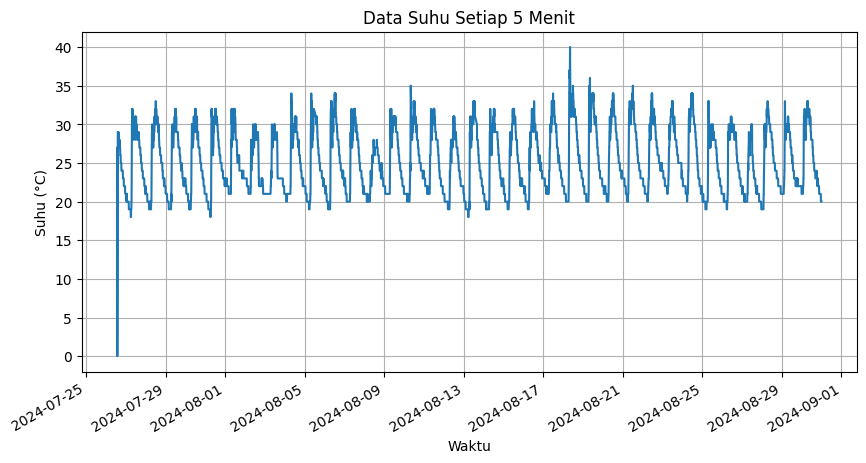

In [7]:
# Menampilkan grafik data suhu (opsional)
df['Suhu'].plot(title='Data Suhu Setiap 5 Menit', figsize=(10,5))
plt.xlabel('Waktu')
plt.ylabel('Suhu (°C)')
plt.grid(True)
plt.show()

In [9]:
data = data.sort_values(by=['Tanggal'], ascending=[False])

In [10]:
# Convert the selected column to numeric, forcing non-numeric values to NaN
data['Suhu'] = pd.to_numeric(data['Suhu'], errors='coerce')


In [11]:
# Mengganti nilai yang hilang dengan nilai median atau metode lain
data = data.fillna(data.median())


C:\Users\sugen\AppData\Local\Temp\ipykernel_12404\1301127926.py:2: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.median())


In [12]:
# Menghitung rata-rata, median, dan standar deviasi dari setiap kolom
mean_temp = data['Suhu'].mean()
median_temp = data['Suhu'].median()
std_temp = data['Suhu'].std()

print(f'Rata-rata suhu: {mean_temp}')
print(f'Median suhu: {median_temp}')
print(f'Standar deviasi suhu: {std_temp}')

Rata-rata suhu: 25.07308075772682
Median suhu: 24.0
Standar deviasi suhu: 4.043997628792056


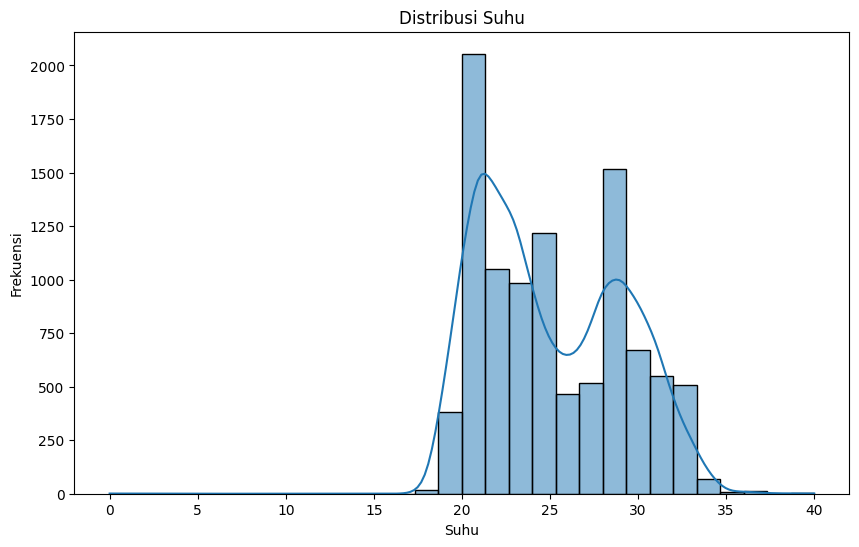

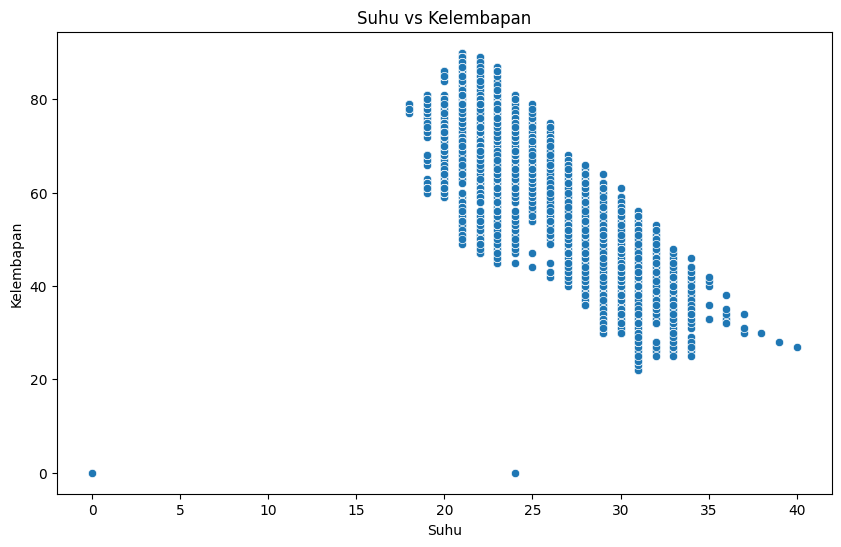

C:\Users\sugen\AppData\Local\Temp\ipykernel_21232\1623353841.py:19: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True, cmap='coolwarm')


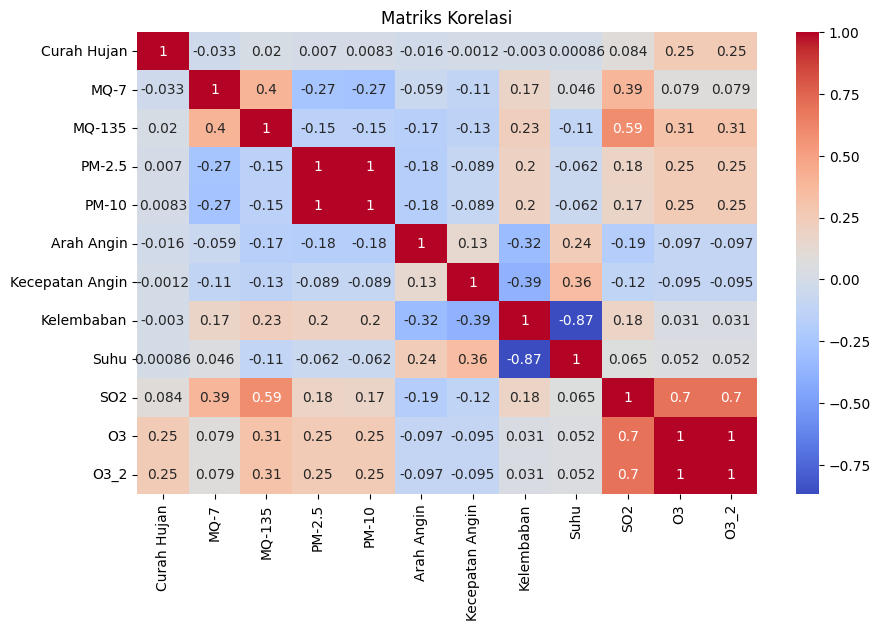

In [19]:
# Histogram suhu
plt.figure(figsize=(10, 6))
sns.histplot(data['Suhu'], bins=30, kde=True)
plt.title('Distribusi Suhu')
plt.xlabel('Suhu')
plt.ylabel('Frekuensi')
plt.show()

# Scatter plot suhu vs kelembapan
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Suhu', y='Kelembaban', data=data)
plt.title('Suhu vs Kelembapan')
plt.xlabel('Suhu')
plt.ylabel('Kelembapan')
plt.show()

# Heatmap untuk melihat korelasi antara variabel
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()

In [21]:
# Analisis korelasi
correlation_matrix = data.corr()
print(correlation_matrix)

# Analisis regresi (contoh sederhana menggunakan linear regression)
from sklearn.linear_model import LinearRegression

# Variabel independen (fitur) dan dependen (target)
X = data[['Suhu', 'Kelembaban', 'Kecepatan Angin']]
y = data['Curah Hujan']

# Membuat model regresi linear
model = LinearRegression()
model.fit(X, y)

# Menampilkan koefisien regresi
print(f'Koefisien regresi: {model.coef_}')
print(f'Intercept: {model.intercept_}')


C:\Users\sugen\AppData\Local\Temp\ipykernel_21232\2878217373.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = data.corr()


                 Curah Hujan      MQ-7    MQ-135    PM-2.5     PM-10  \
Curah Hujan         1.000000 -0.033471  0.020389  0.007011  0.008323   
MQ-7               -0.033471  1.000000  0.397865 -0.265255 -0.270694   
MQ-135              0.020389  0.397865  1.000000 -0.150519 -0.149784   
PM-2.5              0.007011 -0.265255 -0.150519  1.000000  0.999964   
PM-10               0.008323 -0.270694 -0.149784  0.999964  1.000000   
Arah Angin         -0.016356 -0.059358 -0.167836 -0.176757 -0.176249   
Kecepatan Angin    -0.001153 -0.110411 -0.132457 -0.089014 -0.088583   
Kelembaban         -0.002996  0.173525  0.225542  0.201736  0.200088   
Suhu                0.000862  0.046020 -0.106179 -0.061715 -0.061947   
SO2                 0.084364  0.387603  0.590519  0.176868  0.174683   
O3                  0.252611  0.078505  0.309977  0.254252  0.253944   
O3_2                0.252611  0.078505  0.309977  0.254252  0.253944   

                 Arah Angin  Kecepatan Angin  Kelembaban      S

C:\Users\sugen\AppData\Local\Temp\ipykernel_21232\261884880.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  daily_average = data.groupby('Tanggal').mean()


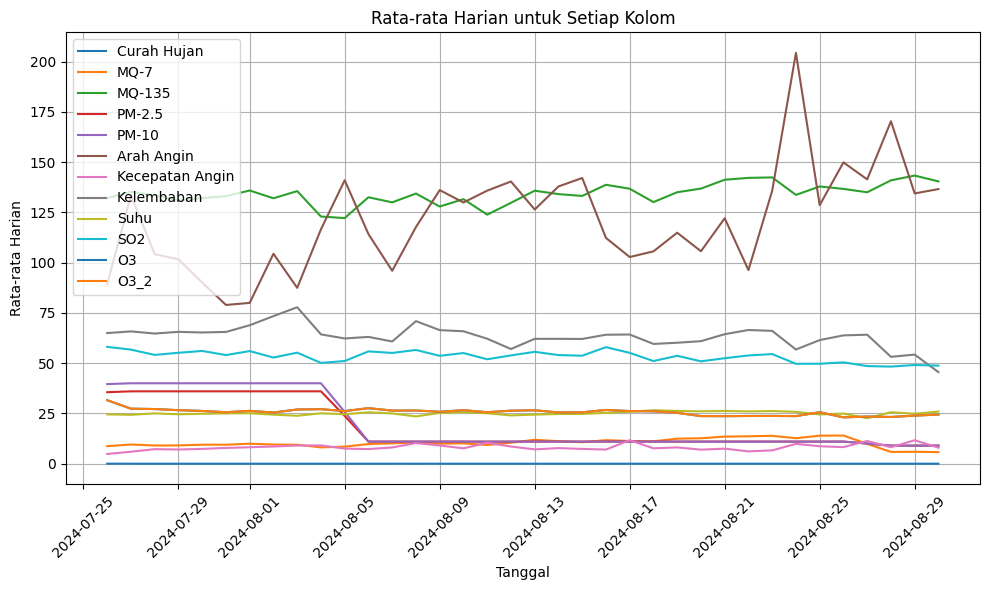

In [20]:
# Pastikan kolom 'Tanggal' dalam format datetime
data['Tanggal'] = pd.to_datetime(data['Tanggal'], format='%d-%m-%y')

# Mengelompokkan data berdasarkan tanggal dan menghitung rata-rata
daily_average = data.groupby('Tanggal').mean()

# Plotting
plt.figure(figsize=(10, 6))

# Plot setiap kolom (kecuali kolom 'Jam' karena tidak relevan untuk rata-rata harian)
for column in daily_average.columns:
    if column != 'Jam':  # atau tambahkan kolom yang tidak ingin di-plot
        plt.plot(daily_average.index, daily_average[column], label=column)

plt.xlabel('Tanggal')
plt.ylabel('Rata-rata Harian')
plt.title('Rata-rata Harian untuk Setiap Kolom')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()